
🔍 Hyperparameter tuning for: size (acres)
✅ Best k: 6
5-fold CV Mean MSE: 86916140.2572
5-fold CV Mean RMSE: 9318.9641
5-fold CV Mean R²: 0.4397


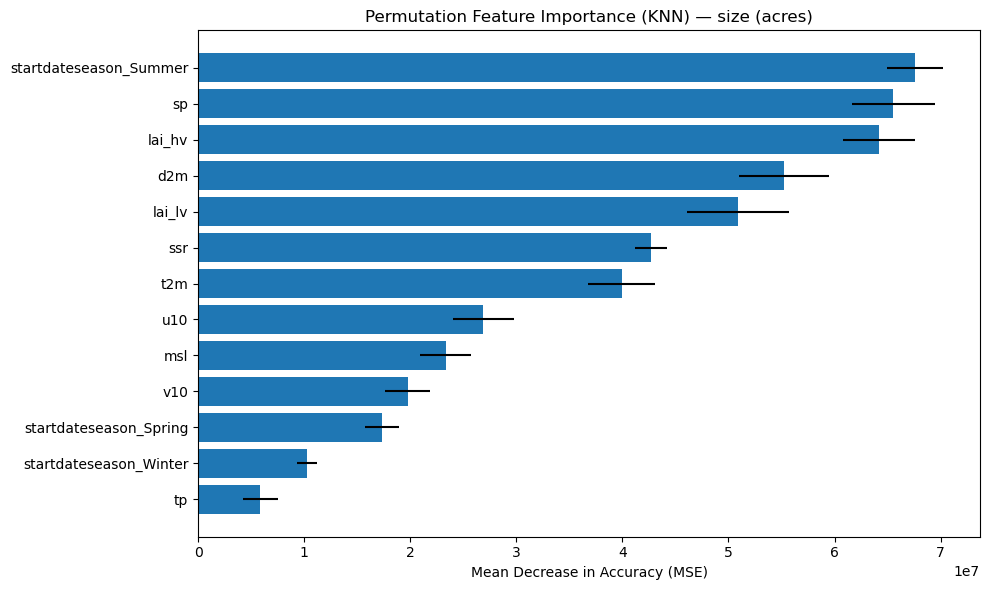


🔍 Hyperparameter tuning for: fire_spread (acres/day)
✅ Best k: 11
5-fold CV Mean MSE: 677826.5574
5-fold CV Mean RMSE: 809.1834
5-fold CV Mean R²: 0.3341


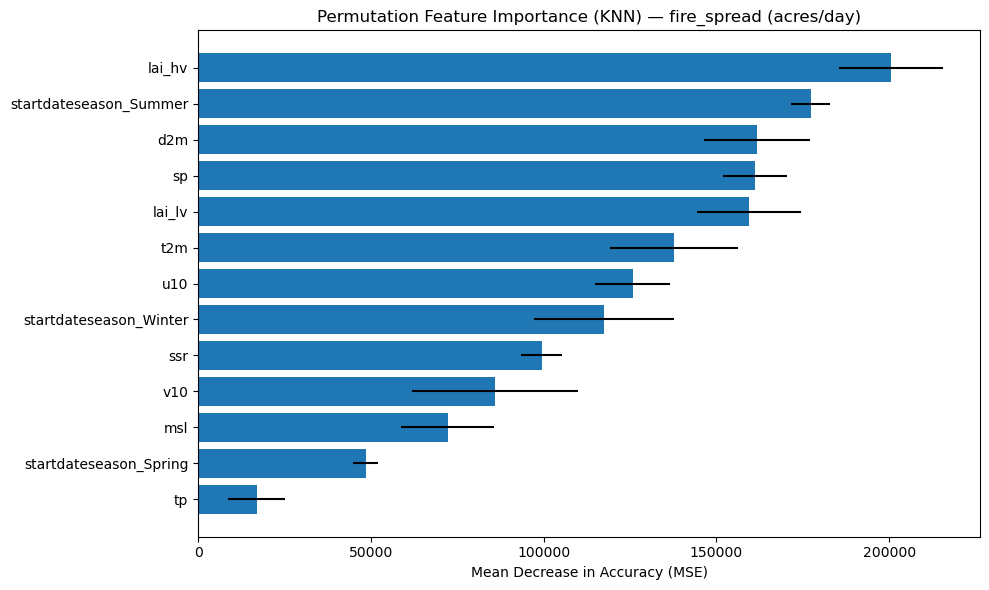


🔍 Hyperparameter tuning for: duration
✅ Best k: 8
5-fold CV Mean MSE: 22.8535
5-fold CV Mean RMSE: 4.7802
5-fold CV Mean R²: 0.3289


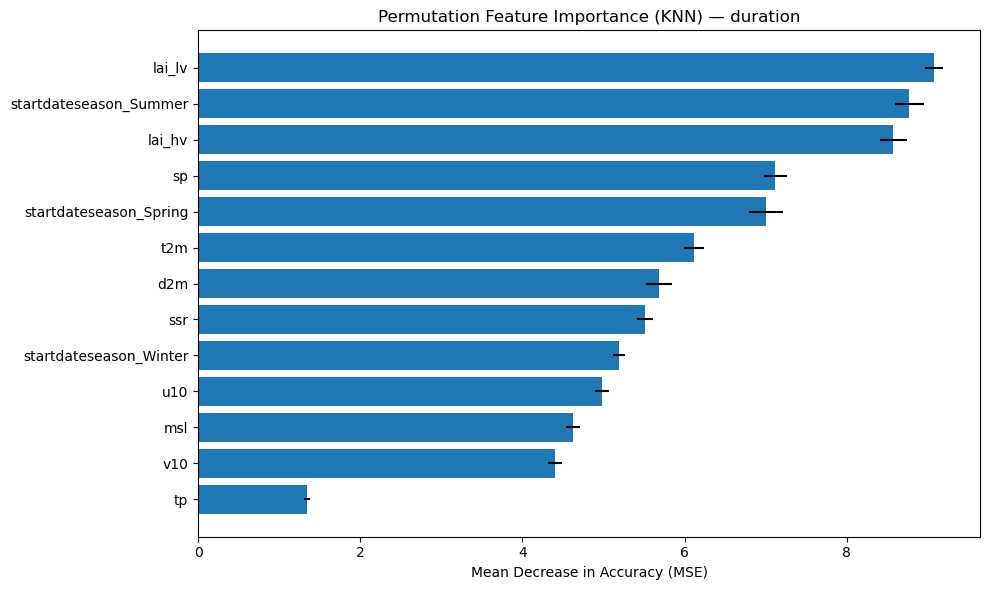

In [1]:
# Load all necessary packages
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Load data. Below line that reads the csv assumes the dataset is in the SAME folder as this script
data = pd.read_csv('full_wildfire_weather_2020_2024.csv')

# Split data randomly into 80% training and 20% testing
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# Create a list of all the predictors used to create model.
all_predictors = ['u10', 'v10', 'd2m', 't2m', 'msl', 'sp', 'lai_hv', 'lai_lv', 'tp', 'ssr', 'startdateseason']
X_full = pd.get_dummies(train_data[all_predictors], columns=['startdateseason'], drop_first=True)

# Create the target variables which model will aim to predict using the predictors from above
targets = {
    'size (acres)': train_data['size (acres)'],
    'fire_spread (acres/day)': train_data['fire_spread (acres/day)'],
    'duration': train_data['duration']
}

# Create variable/object for the 5-Fold Cross Vailidation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define range of k values to try for KNN model
k_values = list(range(3, 16))  # Try k = 3 to 15

# Loop over each target
for name, y in targets.items():
    print(f"\n🔍 Hyperparameter tuning for: {name}")
    best_k = None # this stores the best k value
    best_rmse = float('inf')
    best_scores = {}

    # try all the k values to see how they perform
    for k in k_values:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('knn', KNeighborsRegressor(n_neighbors=k))
        ])

        # Evaluate with 5-fold CV
        neg_mse = cross_val_score(pipeline, X_full, y, cv=kf, scoring='neg_mean_squared_error')
        rmse = np.sqrt(-neg_mse).mean()

        # Record and save the model if it performs the best so far
        if rmse < best_rmse:
            best_rmse = rmse
            best_k = k
            best_scores = {
                'mean_mse': -neg_mse.mean(),
                'mean_rmse': rmse,
                'mean_r2': cross_val_score(pipeline, X_full, y, cv=kf, scoring='r2').mean()
            }

    print(f"✅ Best k: {best_k}")
    print(f"5-fold CV Mean MSE: {best_scores['mean_mse']:.4f}")
    print(f"5-fold CV Mean RMSE: {best_scores['mean_rmse']:.4f}")
    print(f"5-fold CV Mean R²: {best_scores['mean_r2']:.4f}")
    
    # Train final pipeline on full training data for permutation importance
    final_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=best_k))
    ])
    final_pipeline.fit(X_full, y)

    # Permutation Feature Importance
    result = permutation_importance(
        final_pipeline, X_full, y,
        n_repeats=10,
        random_state=42,
        scoring='neg_mean_squared_error'
    )

    importances = result.importances_mean
    std = result.importances_std
    indices = np.argsort(importances)

    # Plot importance
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(indices)), importances[indices], xerr=std[indices], align='center')
    plt.yticks(range(len(indices)), X_full.columns[indices])
    plt.xlabel("Mean Decrease in Accuracy (MSE)")
    plt.title(f"Permutation Feature Importance (KNN) — {name}")
    plt.tight_layout()
    plt.show()